# Caso 4 — Avaliação Quantitativa

Avaliamos o Modelo Vetorial (Caso 2) e o BM25 (Caso 3) com as métricas
Precision@10, Recall@10 e MAP (obrigatórias), além de F1@10, MRR e
NDCG@10 (adicionais). Seguindo o enunciado: um documento é considerado
relevante (para as métricas binárias) quando seu grau de relevância no
qrels é **>= 1**; grau **-1** e documentos não julgados contam como não
relevantes. Para o NDCG, os graus originais (1 a 4) são usados como
relevância graduada.

Os resultados são mantidos **por consulta** (tabela completa) e
**agregados** (média), conforme pedido.


In [1]:
from pathlib import Path
import sys
project_root = Path.cwd()
if not (project_root / "src").is_dir() and (project_root.parent / "src").is_dir():
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

from src.cranfield_data import load_cranfield
from src.pre_processing import load_preprocessed
from src.vector_model import VectorSpaceModel
from src.bm25 import BM25
from src.metrics import evaluate_model

df_docs, df_queries, df_qrels = load_cranfield()
preprocessed = load_preprocessed(project_root / "data" / "processed" / "preprocessed_cranfield.pkl")

CONFIG = "stopwords_stemming"
doc_tokens = preprocessed[CONFIG]["docs"]
query_tokens_list = preprocessed[CONFIG]["queries"]
doc_ids = df_docs["doc_id"].tolist()
query_ids = df_queries["query_id"].tolist()

RESULTS_DIR = project_root / "data" / "processed"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


[cranfield_data] ir_datasets indisponível (RuntimeError: ('All download sources failed', [(RequestsDownload('http://ir.dcs.gla.ac.uk/resources/test_collections/cran/cran.tar.gz', tries=None), HTTPError('403 Client Error: Forbidden for url: http://ir.dcs.gla.ac.uk/resources/test_collections/cran/cran.tar.gz')), (RequestsDownload('https://mirror.ir-datasets.com/1730f7be572d95a5a4b56c59a7b900a5', tries=None), HTTPError('403 Client Error: Forbidden for url: https://mirror.ir-datasets.com/1730f7be572d95a5a4b56c59a7b900a5'))])). Usando arquivos locais em data/raw/ como fallback.


[WARNING] Download failed: 403 Client Error: Forbidden for url: http://ir.dcs.gla.ac.uk/resources/test_collections/cran/cran.tar.gz
[WARNING] Download failed: 403 Client Error: Forbidden for url: https://mirror.ir-datasets.com/1730f7be572d95a5a4b56c59a7b900a5


## Rankings completos para as 225 consultas

In [2]:
# Construção dos dois modelos e ranking de TODAS as 225 consultas
#
# Importante: para que Recall e MAP sejam calculados corretamente, cada
# ranking cobre TODA a coleção (1400 documentos), não apenas o Top-10 —
# do contrário, documentos relevantes fora do Top-10 seriam incorretamente
# tratados como "nunca recuperados" em vez de "recuperados em uma posição
# baixa", o que é a situação real e é justamente o que o Caso 9 (análise
# de erros) precisa poder identificar.
vsm = VectorSpaceModel(doc_tokens)
bm25 = BM25(doc_tokens, k1=1.2, b=0.75)

vsm_rankings, bm25_rankings = {}, {}
for qid, qtoks in zip(query_ids, query_tokens_list):
    vsm_rankings[qid] = [doc_ids[i] for i, _ in vsm.rank(qtoks)]
    bm25_rankings[qid] = [doc_ids[i] for i, _ in bm25.rank(qtoks)]

print(f"Rankings completos calculados para {len(query_ids)} consultas x 2 modelos.")


Rankings completos calculados para 225 consultas x 2 modelos.


## Métricas por consulta

In [3]:
# Avaliação por consulta: Precision@10, Recall@10, MAP (AP por consulta),
# F1@10, MRR e NDCG@10 (estas três últimas como métricas adicionais)
K = 10
vsm_eval = evaluate_model(vsm_rankings, df_qrels, k=K)
bm25_eval = evaluate_model(bm25_rankings, df_qrels, k=K)

print("Métricas por consulta — Modelo Vetorial (5 primeiras linhas):")
display(vsm_eval.head())
print("\nMétricas por consulta — BM25 (5 primeiras linhas):")
display(bm25_eval.head())


Métricas por consulta — Modelo Vetorial (5 primeiras linhas):


,precision@10,recall@10,AP,F1@10,MRR,NDCG@10,n_relevant
query_id,,,,,,,
1,0.4,0.142857,0.169013,0.210526,0.333333,0.151580,28
2,0.4,0.166667,0.253338,0.235294,1.000000,0.130473,24
3,0.7,0.875000,0.633000,0.777778,0.500000,0.735860,8
4,0.1,0.500000,0.540000,0.166667,1.000000,0.613147,2
5,0.3,0.750000,0.284821,0.428571,0.250000,0.279749,4



Métricas por consulta — BM25 (5 primeiras linhas):


,precision@10,recall@10,AP,F1@10,MRR,NDCG@10,n_relevant
query_id,,,,,,,
1,0.3,0.107143,0.226308,0.157895,1.000000,0.193601,28
2,0.5,0.208333,0.236277,0.294118,1.000000,0.218373,24
3,0.7,0.875000,0.655937,0.777778,0.500000,0.740380,8
4,0.1,0.500000,0.550000,0.166667,1.000000,0.613147,2
5,0.3,0.750000,0.327564,0.428571,0.333333,0.343646,4


## Métricas agregadas

In [4]:
# Métricas agregadas (média sobre as 225 consultas)
agg = pd.DataFrame({
    "Modelo Vetorial": vsm_eval.drop(columns="n_relevant").mean(),
    "BM25": bm25_eval.drop(columns="n_relevant").mean(),
})
agg.index.name = "Métrica"
display(agg.round(4))


,Modelo Vetorial,BM25
Métrica,,
precision@10,0.2169,0.2347
recall@10,0.3785,0.3946
AP,0.2763,0.3081
F1@10,0.2488,0.2659
MRR,0.4868,0.5446
NDCG@10,0.2771,0.3065


## Distribuição de desempenho por consulta

A média agregada esconde a variabilidade entre consultas — o histograma
abaixo mostra que ambos os modelos têm uma quantidade considerável de
consultas com AP muito baixo (perto de 0) e um grupo menor com AP alto
(perto de 1), mais do que uma distribuição concentrada em torno da média.
Essa variabilidade é explorada em detalhe nos Casos 5 e 6.


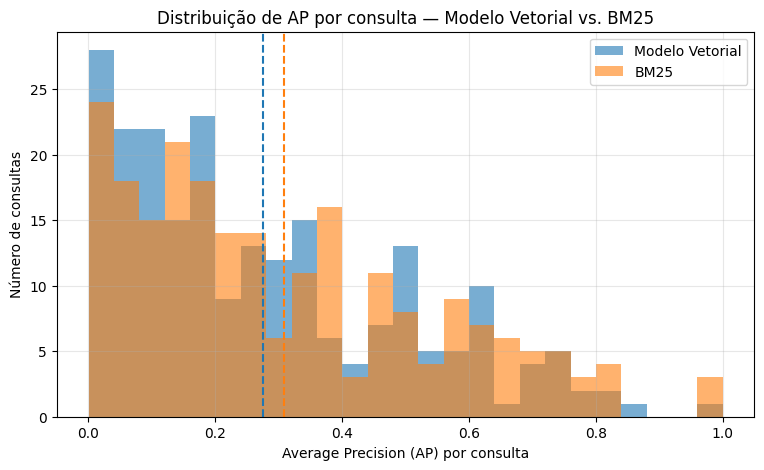

In [5]:
# Distribuição de Average Precision (AP) por consulta, para cada modelo
plt.figure(figsize=(9, 5))
plt.hist(vsm_eval["AP"], bins=25, alpha=0.6, label="Modelo Vetorial")
plt.hist(bm25_eval["AP"], bins=25, alpha=0.6, label="BM25")
plt.axvline(vsm_eval["AP"].mean(), color="C0", linestyle="--", linewidth=1.5)
plt.axvline(bm25_eval["AP"].mean(), color="C1", linestyle="--", linewidth=1.5)
plt.xlabel("Average Precision (AP) por consulta")
plt.ylabel("Número de consultas")
plt.title("Distribuição de AP por consulta — Modelo Vetorial vs. BM25")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## Persistência dos resultados

In [6]:
# Persistindo os resultados para reuso nos Casos 5, 6 e 9 (evita
# reconstruir os modelos e garante que todas as análises seguintes usem
# EXATAMENTE os mesmos rankings desta avaliação).
vsm_eval.to_csv(RESULTS_DIR / "vsm_perquery.csv")
bm25_eval.to_csv(RESULTS_DIR / "bm25_perquery.csv")
with open(RESULTS_DIR / "vsm_rankings.pkl", "wb") as f:
    pickle.dump(vsm_rankings, f)
with open(RESULTS_DIR / "bm25_rankings.pkl", "wb") as f:
    pickle.dump(bm25_rankings, f)
print("Resultados salvos em", RESULTS_DIR)


Resultados salvos em /home/claude/ir_project/data/processed
